# forecast-v2 Tabular Model — Process Demonstration

Sprint 4 forecast-v2 baseline: tabular regression (Ridge / RandomForest / GradientBoosting)
with dynamic + time features. Follows the `forecast-v2` SOP from `docs/memory/Sprint3-4_execution-plan.md`.

## 1. Setup

In [1]:
import sys
from pathlib import Path

HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import forecast_v2_feature_pipeline as fp
import forecast_v2_model as fm
import forecast_v2_writer as fw

print('Modules loaded OK')
print(f'Dynamic features: {len(fp.DYNAMIC_FEATURES)}')
print(f'Time features: {len(fp.TIME_FEATURES)}')

Modules loaded OK
Dynamic features: 18
Time features: 13


## 2. Data Loading

Two modes: **Synthetic** (default, `build_synthetic_data()`) or **Live DB** (`fp.load_venues()`, etc.).

In [2]:
venues, scores, reports = fp.build_synthetic_data(n_venues=30, hours_back=168, seed=42)

print(f'Venues:  {len(venues)}')
print(f'Scores:  {len(scores)} rows, {scores["venue_id"].nunique()} venues')
print(f'Reports: {len(reports)} rows')
print(f'Score range: {scores["score"].min():.0f} - {scores["score"].max():.0f}')
print(f'Time range:  {scores["forecast_start_time"].min()} -> {scores["forecast_start_time"].max()}')

print(f'\nDistricts: {venues["district"].nunique()}')
print(venues['district'].value_counts().to_string())

Venues:  30
Scores:  5040 rows, 30 venues
Reports: 504 rows
Score range: 1 - 100
Time range:  2026-06-29 17:00:00+00:00 -> 2026-07-06 16:00:00+00:00

Districts: 8
district
Midtown               4
Downtown              4
Upper_East            4
Upper_West            4
Harlem                4
Chelsea               4
SoHo                  3
Financial_District    3


## 3. Feature Engineering

### Dynamic Features (lookback from forecast_for)
- `latest_busyness_score` / `latest_busyness_age_minutes` — most recent score
- `rolling_mean_1h/3h`, `rolling_max_3h` — rolling aggregations
- `recent_report_count_1h/3h` — crowd report density
- `active_report_severity_score` — recency-weighted severity
- `district_live_density` — concurrent venue activity in same district
- `venue_capacity_bucket`, `availability_penalty`

### Time Features
- `hour_of_day`, `day_of_week`, `is_weekend`, `is_business_hours`
- `time_bucket`, `forecast_offset_hours`, `target_hour_of_day`
- `minutes_until_close`, `minutes_since_open`
- `is_holiday_or_event_stub` (fixed to 0)

In [3]:
# Build training samples
training = fp.build_training_samples(scores, venues, reports, max_samples_per_venue=48)
print(f'Training samples: {len(training)} rows x {len(training.columns)} columns')

# Build prediction samples (12h horizon)
pred_samples = fp.build_prediction_samples(venues, scores, reports)
print(f'Prediction samples: {len(pred_samples)} rows')

# Missing value audit
missing_cols = [c for c in training.columns if c.endswith('_missing')]
for col in missing_cols:
    pct = training[col].mean() * 100
    if pct > 0:
        print(f'  {col}: {pct:.1f}% flagged missing')

Training samples: 1440 rows x 66 columns
Prediction samples: 360 rows
  latest_score_missing: 2.1% flagged missing
  rolling_mean_1h_missing: 2.1% flagged missing
  rolling_mean_3h_missing: 2.1% flagged missing
  rolling_max_3h_missing: 2.1% flagged missing
  recent_report_count_1h_missing: 7.2% flagged missing
  recent_report_count_3h_missing: 7.2% flagged missing
  active_report_severity_score_missing: 7.2% flagged missing
  holiday_missing: 100.0% flagged missing
  citibike_activity_missing: 100.0% flagged missing
  mta_disruption_missing: 100.0% flagged missing
  mta_arrival_missing: 100.0% flagged missing


## 4. Training — Time-Based Split

Per SOP: **time-based split only**. Earlier timestamps -> train (70%), middle -> val (15%), later -> test (15%). No random split.

In [4]:
available = [c for c in fm.ALL_FEATURES if c in training.columns]
missing_f = [c for c in fm.ALL_FEATURES if c not in training.columns]
print(f'Features: {len(available)}/{len(fm.ALL_FEATURES)} available')
if missing_f:
    print(f'Missing: {missing_f}')

metrics, fitted_pipelines, test_preds = fm.train_and_evaluate(training, available)

Features: 61/61 available
Time split: train=1007, val=217, test=216
  train range: 2026-06-29 17:00:00+00:00 → 2026-07-04 14:00:00+00:00
  val   range: 2026-07-04 14:00:00+00:00 → 2026-07-05 15:00:00+00:00
  test  range: 2026-07-05 15:00:00+00:00 → 2026-07-06 16:00:00+00:00
  numeric features: 53, categorical: 8

  Training Ridge...

  Training RandomForestRegressor...

  Training GradientBoostingRegressor...


## 5. Model Evaluation

In [5]:
display_cols = ['model_name', 'split', 'mae', 'rmse', 'r2', 'accuracy', 'macro_f1']
main_metrics = metrics[~metrics['split'].str.startswith('test_')]
print(main_metrics[display_cols].to_string(index=False))

test_m = main_metrics[main_metrics['split'] == 'test']
best = test_m.loc[test_m['mae'].idxmin()]
print(f'\nBest model (test MAE): {best["model_name"]} — MAE={best["mae"]:.3f}, R2={best["r2"]:.3f}')

               model_name split   mae  rmse    r2  accuracy  macro_f1
                    Ridge train 5.395 7.340 0.911     0.802     0.792
                    Ridge   val 5.847 7.788 0.901     0.779     0.773
                    Ridge  test 6.195 8.314 0.887     0.810     0.800
    RandomForestRegressor train 1.610 2.334 0.991     0.943     0.941
    RandomForestRegressor   val 3.916 5.335 0.954     0.876     0.872
    RandomForestRegressor  test 4.048 5.487 0.951     0.843     0.846
GradientBoostingRegressor train 2.676 3.497 0.980     0.905     0.904
GradientBoostingRegressor   val 4.114 5.650 0.948     0.876     0.870
GradientBoostingRegressor  test 4.158 5.493 0.951     0.815     0.817

Best model (test MAE): RandomForestRegressor — MAE=4.048, R2=0.951


In [6]:
# Per-bucket evaluation
bucket_m = metrics[metrics['split'].str.startswith('test_')]
print('Per-bucket (test set):')
print(bucket_m[['model_name', 'split', 'mae', 'rmse']].to_string(index=False))

Per-bucket (test set):
               model_name         split   mae   rmse
                    Ridge    test_quiet 3.594  4.400
                    Ridge test_moderate 6.568  8.021
                    Ridge     test_busy 9.777 12.565
    RandomForestRegressor    test_quiet 2.970  4.351
    RandomForestRegressor test_moderate 3.967  4.928
    RandomForestRegressor     test_busy 5.932  7.622
GradientBoostingRegressor    test_quiet 2.997  3.981
GradientBoostingRegressor test_moderate 4.284  5.469
GradientBoostingRegressor     test_busy 5.823  7.336


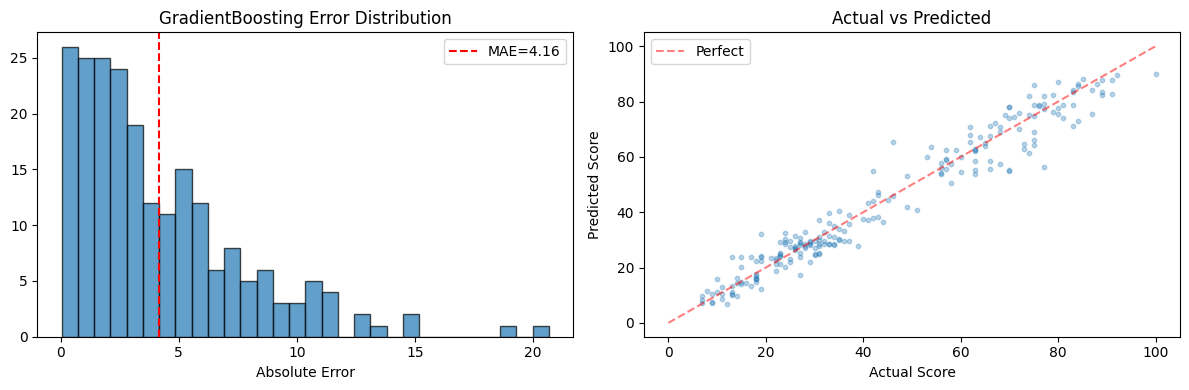

In [7]:
# Error distribution
gbm_preds = test_preds[test_preds['model_name'] == 'GradientBoostingRegressor']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gbm_preds['abs_error'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(gbm_preds['abs_error'].mean(), color='red', linestyle='--',
                label=f'MAE={gbm_preds["abs_error"].mean():.2f}')
axes[0].set_xlabel('Absolute Error')
axes[0].set_title('GradientBoosting Error Distribution')
axes[0].legend()

axes[1].scatter(gbm_preds['label_score'], gbm_preds['predicted_score'], alpha=0.3, s=10)
axes[1].plot([0, 100], [0, 100], 'r--', alpha=0.5, label='Perfect')
axes[1].set_xlabel('Actual Score')
axes[1].set_ylabel('Predicted Score')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Prediction Curve (prediction_curve_v2.csv)

In [8]:
gbm = fitted_pipelines['GradientBoostingRegressor']
curve = fm.generate_prediction_curves(gbm, pred_samples, available, 'GradientBoostingRegressor')

print(f'Rows: {len(curve)}, Venues: {curve["venue_id"].nunique()}')
print(f'Score range: [{curve["predicted_score"].min():.1f}, {curve["predicted_score"].max():.1f}]')
print(f'Level distribution:')
print(curve['predicted_level'].value_counts().to_string())

offsets = curve.groupby('venue_id')['offset_hours'].nunique()
print(f'\nVenues with full 12h: {(offsets == 12).sum()}/{len(offsets)}')

Rows: 360, Venues: 30
Score range: [11.5, 86.4]
Level distribution:
predicted_level
quiet       171
moderate    155
busy         34

Venues with full 12h: 30/30


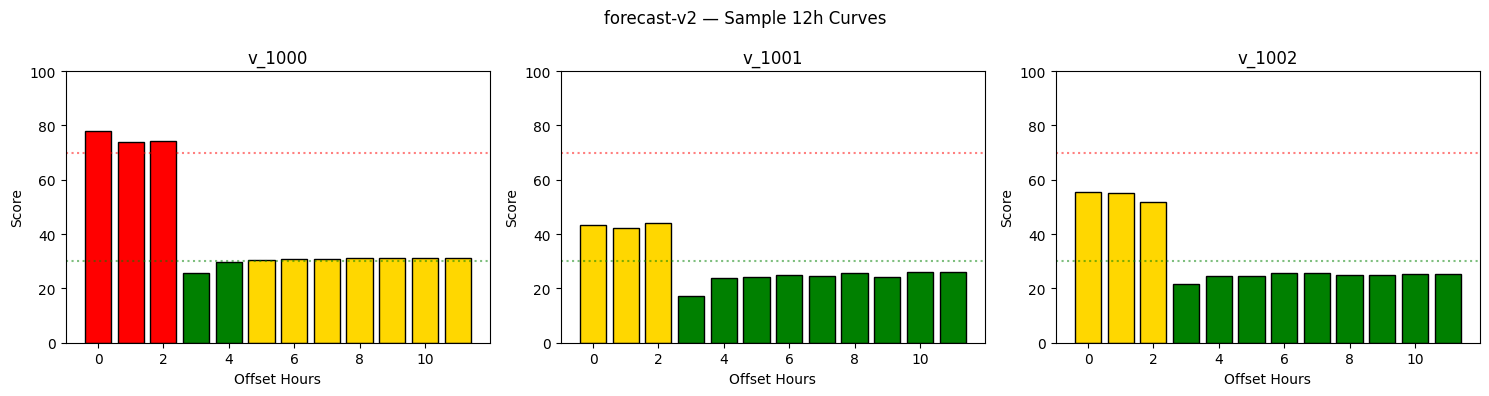

In [9]:
# Sample forecast curves
sample_vids = curve['venue_id'].unique()[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, vid in enumerate(sample_vids):
    vc = curve[curve['venue_id'] == vid].sort_values('offset_hours')
    colors = ['green' if l == 'quiet' else 'gold' if l == 'moderate' else 'red'
              for l in vc['predicted_level']]
    axes[i].bar(vc['offset_hours'], vc['predicted_score'], color=colors, edgecolor='black')
    axes[i].axhline(30, color='green', linestyle=':', alpha=0.5)
    axes[i].axhline(70, color='red', linestyle=':', alpha=0.5)
    axes[i].set_xlabel('Offset Hours')
    axes[i].set_ylabel('Score')
    axes[i].set_title(vid)
    axes[i].set_ylim(0, 100)

plt.suptitle('forecast-v2 — Sample 12h Curves')
plt.tight_layout()
plt.show()

## 7. Save Outputs

In [10]:
OUTPUT = HERE / 'output'
OUTPUT.mkdir(exist_ok=True)

training.to_csv(OUTPUT / 'forecast_v2_training_features.csv', index=False)
pred_samples.to_csv(OUTPUT / 'forecast_v2_prediction_features.csv', index=False)
metrics.to_csv(OUTPUT / 'forecast_v2_model_metrics.csv', index=False)
test_preds.to_csv(OUTPUT / 'forecast_v2_test_predictions.csv', index=False)
curve.to_csv(OUTPUT / 'prediction_curve_v2.csv', index=False)

missing_audit = fp.summarize_missing(training)
missing_audit.to_csv(OUTPUT / 'forecast_v2_feature_missing_audit.csv', index=False)

print('Saved to', str(OUTPUT))
for f in sorted(OUTPUT.glob('*.csv')):
    rows = sum(1 for _ in open(f)) - 1
    print(f'  {f.name}: {rows} rows')

Saved to /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/7.6-7.11/output
  forecast_v2_feature_missing_audit.csv: 62 rows
  forecast_v2_model_metrics.csv: 18 rows
  forecast_v2_prediction_features.csv: 360 rows
  forecast_v2_test_predictions.csv: 648 rows
  forecast_v2_training_features.csv: 1440 rows
  prediction_curve_v2.csv: 360 rows


## 8. DB Write (dry-run)

In [11]:
!python forecast_v2_writer.py --dry-run --csv output/prediction_curve_v2.csv --model-version forecast-v2

Loaded 360 forecast rows for 30 venues (model_version=forecast-v2)

-- DRY RUN: 360 upserts would be emitted --
INSERT INTO busyness_forecasts (venue_id, forecast_for, predicted_score, predicted_level, estimated_wait_minutes, model_version) VALUES ('v_1000', '2026-07-06 16:00:00', 78, 'busy', NULL, 'forecast-v2') ON DUPLICATE KEY UPDATE predicted_score = VALUES(predicted_score), predicted_level = VALUES(predicted_level), estimated_wait_minutes = VALUES(estimated_wait_minutes);
INSERT INTO busyness_forecasts (venue_id, forecast_for, predicted_score, predicted_level, estimated_wait_minutes, model_version) VALUES ('v_1000', '2026-07-06 17:00:00', 74, 'busy', NULL, 'forecast-v2') ON DUPLICATE KEY UPDATE predicted_score = VALUES(predicted_score), predicted_level = VALUES(predicted_level), estimated_wait_minutes = VALUES(estimated_wait_minutes);
INSERT INTO busyness_forecasts (venue_id, forecast_for, predicted_score, predicted_level, estimated_wait_minutes, model_version) VALUES ('v_1000', '

## 9. Known Limitations

- **Synthetic data**: `bootstrap_label=true` — labels are synthetic, not real future busyness_scores
- **No holiday/event data**: `is_holiday_or_event_stub` = 0
- **No weather/transit**: v2 placeholder features not implemented
- **Opening hours**: heuristic only (8AM-8PM default); DB field is free text
- **ARIMA/LSTM excluded**: methodology frozen to tabular baseline per SOP